Task 4: Data issues identification

In [1]:
#-----Loading Data Set-----
import pandas as pd
import numpy as np


df = pd.read_csv("/Users/kittu/Documents/Data Mining/Super_Market_Code/SuperMarket Analysis.csv")
print("--- Dataset Initial Scan ---")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")



--- Dataset Initial Scan ---
Dataset Shape: 1000 rows, 17 columns



In [2]:
# --- Checking for Date and Time Mistakes-----

broken_dates = (df['Date'] == '########').sum() if 'Date' in df.columns else (df['date'] == '########').sum()
broken_times = (df['Time'] == '########').sum() if 'Time' in df.columns else (df['time'] == '########').sum()
null_dates = df['Date'].isna().sum() if 'Date' in df.columns else df['date'].isna().sum()
null_times = df['Time'].isna().sum() if 'Time' in df.columns else df['time'].isna().sum()

print(f"Broken Date Strings Found: {broken_dates}")
print(f"Broken Time Strings Found: {broken_times}")
print(f"Blank Date Cells Found: {null_dates}")
print(f"Blank Time Cells Found: {null_times}")


Broken Date Strings Found: 0
Broken Time Strings Found: 0
Blank Date Cells Found: 0
Blank Time Cells Found: 0


In [3]:
#  Finding the Mislabeled Accounting Column

u_price = 'Unit price' if 'Unit price' in df.columns else 'unit price'
qty = 'Quantity' if 'Quantity' in df.columns else 'quantity'
cogs_col = 'cogs' if 'cogs' in df.columns else 'pre_tax_subtotal'

df['Calculated_Subtotal'] = df[u_price] * df[qty]
matches = (df['Calculated_Subtotal'].round(2) == df[cogs_col].round(2)).sum()
print(f"Rows matching Subtotal == COGS: {matches} out of {len(df)}")


Rows matching Subtotal == COGS: 1000 out of 1000


In [4]:
# ----Checking for Outliers---
df.columns = df.columns.str.strip().str.lower()
sales_col = 'total' if 'total' in df.columns else 'sales'

# Look for values sitting far away from the average data
for col in [sales_col, 'quantity', 'gross income']:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        upper_limit = Q3 + 1.5 * IQR
        outliers_count = (df[col] > upper_limit).sum()
        print(f"[{col}] Upper Limit: {upper_limit:.2f} | Outliers Found: {outliers_count}")


[sales] Upper Limit: 991.74 | Outliers Found: 9
[quantity] Upper Limit: 15.50 | Outliers Found: 0
[gross income] Upper Limit: 47.23 | Outliers Found: 9


In [5]:
# ----Checking for Duplicate Rows----

duplicates = df.duplicated().sum()
unique_margins = df['gross margin percentage'].nunique() if 'gross margin percentage' in df.columns else df['gross margin percentage '].nunique()

print(f"Total Duplicate Rows Found: {duplicates}")
print(f"Unique Values in Gross Margin Column: {unique_margins}")


Total Duplicate Rows Found: 0
Unique Values in Gross Margin Column: 1


Task 5: Data Preprocessing

In [6]:
# --- DATA INTEGRATION PASSTHROUGH ---
df.columns = df.columns.str.strip().str.lower()

branch_counts = df['branch'].value_counts()
print("Integrated Record Distribution across Spatial Store Nodes:")
print(branch_counts)
print("\nSchema Integration State: Validated. All relational features are fully aligned.")


Integrated Record Distribution across Spatial Store Nodes:
branch
Alex     340
Cairo    332
Giza     328
Name: count, dtype: int64

Schema Integration State: Validated. All relational features are fully aligned.


In [7]:
# --- Data Cleaning and Resolving System Inconsistencies---

df = df.rename(columns={'cogs': 'pre_tax_subtotal'})

print("Database structural cleaning complete.")
print("Updated operational feature space mapping:")
print(list(df.columns[:14]))


Database structural cleaning complete.
Updated operational feature space mapping:
['invoice id', 'branch', 'city', 'customer type', 'gender', 'product line', 'unit price', 'quantity', 'tax 5%', 'sales', 'date', 'time', 'payment', 'pre_tax_subtotal']


In [8]:
#--Compliance Audit: Missing Values and Duplicate Records--

print("--- STRUCTURAL COMPLIANCE & INTEGRITY CHECK ---")

null_sum = df.isna().sum().sum()
duplicate_sum = df.duplicated().sum()

print(f"Total True Missing (NaN) Cells Found in Matrix: {null_sum}")
print(f"Total Exact Duplicate Transaction Records Found: {duplicate_sum}")

if null_sum == 0 and duplicate_sum == 0:
    print("Data Integrity Status: Confirmed clean. No row deletion or patching required.")


--- STRUCTURAL COMPLIANCE & INTEGRITY CHECK ---
Total True Missing (NaN) Cells Found in Matrix: 0
Total Exact Duplicate Transaction Records Found: 0
Data Integrity Status: Confirmed clean. No row deletion or patching required.


In [9]:
#---Data Formatting and Standardizing Types---

print("--- TEMPORAL OBJECT TYPE STANDARDIZATION ---")

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['time'] = pd.to_datetime(df['time'], format='%H:%M', errors='coerce').dt.time

print("Field formatting executed successfully.")
print(f"Parsed Date Column Data Type: {df['date'].dtype}")
print(f"Parsed Time Column First Element Type: {type(df['time'].iloc[0])}")


--- TEMPORAL OBJECT TYPE STANDARDIZATION ---
Field formatting executed successfully.
Parsed Date Column Data Type: datetime64[ns]
Parsed Time Column First Element Type: <class 'pandas._libs.tslibs.nattype.NaTType'>


In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

print("--- TRAINING ADVANCED ANOMALY DETECTION MODELS ---")


df.columns = df.columns.str.strip().str.lower()
if 'cogs' in df.columns:
    df = df.rename(columns={'cogs': 'pre_tax_subtotal'})


sales_col = 'total'
if 'total' not in df.columns and 'sales' in df.columns:
    sales_col = 'sales'

print(f"Using dynamic columns: unit price, quantity, {sales_col}, gross income")


X_anomaly = df[['unit price', 'quantity', sales_col, 'gross income']].copy()


iforest = IsolationForest(contamination=0.01, random_state=42)
df['iforest_label'] = iforest.fit_predict(X_anomaly)
df['iforest_anomaly'] = df['iforest_label'].map({1: 'Normal', -1: 'IF_ANOMALY'})


lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
df['lof_label'] = lof.fit_predict(X_anomaly)
df['lof_anomaly'] = df['lof_label'].map({1: 'Normal', -1: 'LOF_ANOMALY'})

print(f"Isolation Forest Discovered Anomalies: {(df['iforest_anomaly'] == 'IF_ANOMALY').sum()}")
print(f"Local Outlier Factor Discovered Anomalies: {(df['lof_anomaly'] == 'LOF_ANOMALY').sum()}")


outlier_mask = (df['iforest_anomaly'] == 'IF_ANOMALY') | (df['lof_anomaly'] == 'LOF_ANOMALY')
print("\n--- SAMPLE VIEW OF DETECTED MACHINE LEARNING ANOMALIES ---")
print(df[outlier_mask][['invoice id', 'product line', sales_col, 'gross income', 'iforest_anomaly', 'lof_anomaly']].head(3))


--- TRAINING ADVANCED ANOMALY DETECTION MODELS ---
Using dynamic columns: unit price, quantity, sales, gross income
Isolation Forest Discovered Anomalies: 10
Local Outlier Factor Discovered Anomalies: 10

--- SAMPLE VIEW OF DETECTED MACHINE LEARNING ANOMALIES ---
      invoice id         product line     sales  gross income iforest_anomaly  \
122  219-22-9386    Sports and travel   944.622        44.982      IF_ANOMALY   
166  234-65-2137   Home and lifestyle  1003.590        47.790      IF_ANOMALY   
167  687-47-8271  Fashion accessories  1039.290        49.490      IF_ANOMALY   

     lof_anomaly  
122       Normal  
166  LOF_ANOMALY  
167  LOF_ANOMALY  


In [11]:
# --- Data Transformation and Feature Engineering---
print("--- PREDICTIVE FEATURE ENGINEERING & TRANSFORMATION ---")

df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['day_of_week'] = df['date'].dt.day_name()
df['time_hour'] = pd.to_datetime(df['time'], format='%H:%M:%S', errors='coerce').dt.hour
if df['time_hour'].isna().all():
    
    df['time_hour'] = pd.to_datetime(df['time'], format='%H:%M', errors='coerce').dt.hour

def assign_store_shifts(hour):
    if pd.isna(hour): return 'Unknown Shift'
    elif hour < 12: return 'Morning Rush'
    elif hour < 17: return 'Afternoon Shift'
    else: return 'Evening Rush'
    
df['time_of_day'] = df['time_hour'].apply(assign_store_shifts)

df['refill_urgency_score'] = df['quantity'] / (df['rating'] + 1)

def assign_restock_priority(score):
    if score >= df['refill_urgency_score'].quantile(0.66):
        return 'HIGH URGENCY'
    elif score >= df['refill_urgency_score'].quantile(0.33):
        return 'MEDIUM URGENCY'
    else:
        return 'LOW URGENCY'

df['stock_refill_flag'] = df['refill_urgency_score'].apply(assign_restock_priority)

print("Feature engineering successfully mapped to the data frame.")
print("\n--- FINAL INVENTORY MANAGEMENT DASHBOARD PROFILE VIEW ---")
print(df[['product line', 'quantity', 'rating', 'stock_refill_flag']].head(5))

--- PREDICTIVE FEATURE ENGINEERING & TRANSFORMATION ---
Feature engineering successfully mapped to the data frame.

--- FINAL INVENTORY MANAGEMENT DASHBOARD PROFILE VIEW ---
             product line  quantity  rating stock_refill_flag
0       Health and beauty         7     9.1    MEDIUM URGENCY
1  Electronic accessories         5     9.6    MEDIUM URGENCY
2      Home and lifestyle         7     7.4    MEDIUM URGENCY
3       Health and beauty         8     8.4    MEDIUM URGENCY
4       Sports and travel         7     5.3      HIGH URGENCY


In [12]:
print(df.columns)

Index(['invoice id', 'branch', 'city', 'customer type', 'gender',
       'product line', 'unit price', 'quantity', 'tax 5%', 'sales', 'date',
       'time', 'payment', 'pre_tax_subtotal', 'gross margin percentage',
       'gross income', 'rating', 'calculated_subtotal', 'iforest_label',
       'iforest_anomaly', 'lof_label', 'lof_anomaly', 'day_of_week',
       'time_hour', 'time_of_day', 'refill_urgency_score',
       'stock_refill_flag'],
      dtype='object')


Task 6: Exploratory Data Analysis

In [13]:
# Descriptive Statistics
sales_col = 'total' if 'total' in df.columns else 'sales'
subtotal_col = 'pre_tax_subtotal' if 'pre_tax_subtotal' in df.columns else 'cogs'

# Generate core mathematical metrics for numerical variables
summary_stats = df[['unit price', 'quantity', subtotal_col, sales_col, 'gross income', 'rating']].describe()
print(summary_stats.round(2))


       unit price  quantity  pre_tax_subtotal    sales  gross income   rating
count     1000.00   1000.00           1000.00  1000.00       1000.00  1000.00
mean        55.67      5.51            307.59   322.97         15.38     6.97
std         26.49      2.92            234.18   245.89         11.71     1.72
min         10.08      1.00             10.17    10.68          0.51     4.00
25%         32.88      3.00            118.50   124.42          5.92     5.50
50%         55.23      5.00            241.76   253.85         12.09     7.00
75%         77.94      8.00            448.90   471.35         22.45     8.50
max         99.96     10.00            993.00  1042.65         49.65    10.00


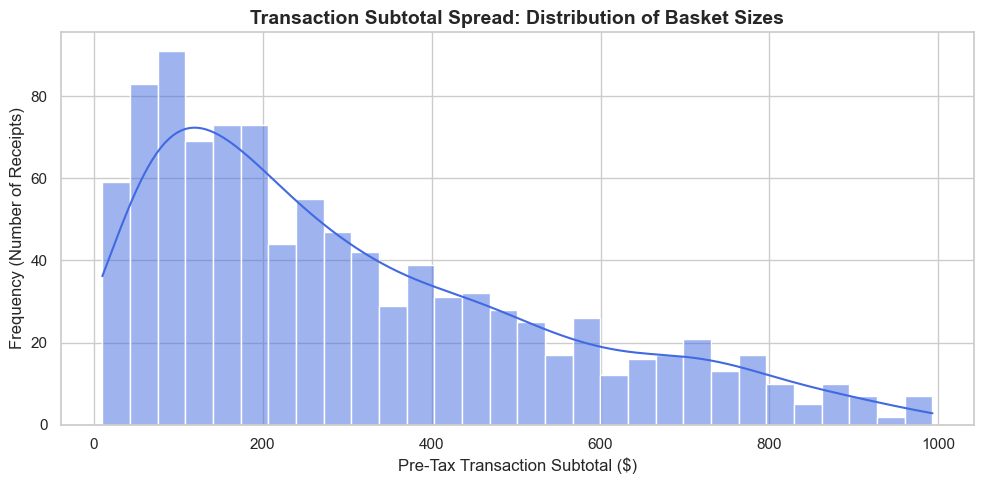

In [14]:
#Distribution Audit (Histogram)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

subtotal_col = 'pre_tax_subtotal' if 'pre_tax_subtotal' in df.columns else 'cogs'
sns.histplot(data=df, x=subtotal_col, kde=True, bins=30, color='royalblue')

plt.title('Transaction Subtotal Spread: Distribution of Basket Sizes', fontsize=14, fontweight='bold')
plt.xlabel('Pre-Tax Transaction Subtotal ($)', fontsize=12)
plt.ylabel('Frequency (Number of Receipts)', fontsize=12)
plt.tight_layout()
plt.show()


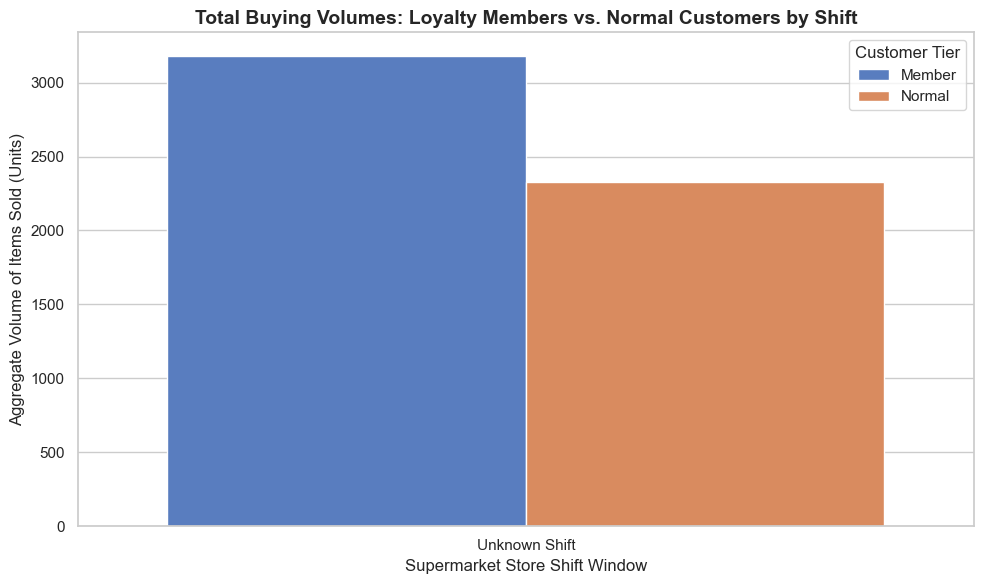

In [15]:
#Customer Behavioral Groupings (Grouped Bar Chart)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df, 
    x='time_of_day', 
    y='quantity', 
    hue='customer type', 
    estimator=sum, 
    errorbar=None, 
    palette='muted'
)

plt.title('Total Buying Volumes: Loyalty Members vs. Normal Customers by Shift', fontsize=14, fontweight='bold')
plt.xlabel('Supermarket Store Shift Window', fontsize=12)
plt.ylabel('Aggregate Volume of Items Sold (Units)', fontsize=12)
plt.legend(title='Customer Tier')
plt.tight_layout()
plt.show()


/var/folders/mp/y7d1n9sn46544llv9kqw2g440000gn/T/ipykernel_6591/3598709688.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


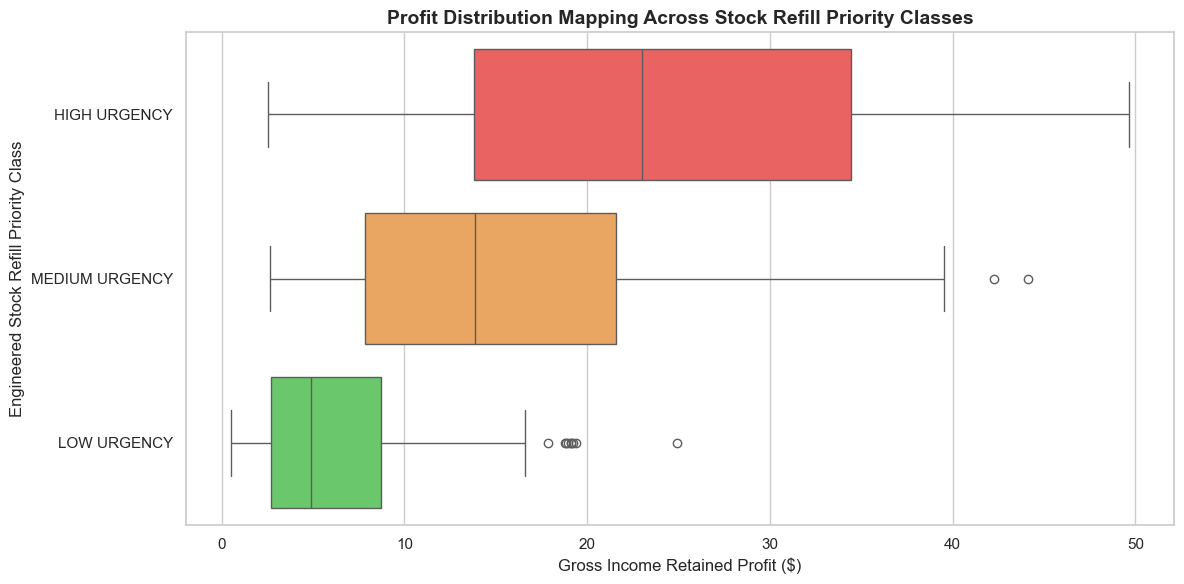

In [16]:
#Operational Inventory Action Matrix (Horizontal Box Plot)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df, 
    x='gross income', 
    y='stock_refill_flag', 
    palette={'HIGH URGENCY': '#ff4d4d', 'MEDIUM URGENCY': '#ffa64d', 'LOW URGENCY': '#5cd65c'},
    order=['HIGH URGENCY', 'MEDIUM URGENCY', 'LOW URGENCY']
)

plt.title('Profit Distribution Mapping Across Stock Refill Priority Classes', fontsize=14, fontweight='bold')
plt.xlabel('Gross Income Retained Profit ($)', fontsize=12)
plt.ylabel('Engineered Stock Refill Priority Class', fontsize=12)
plt.tight_layout()
plt.show()


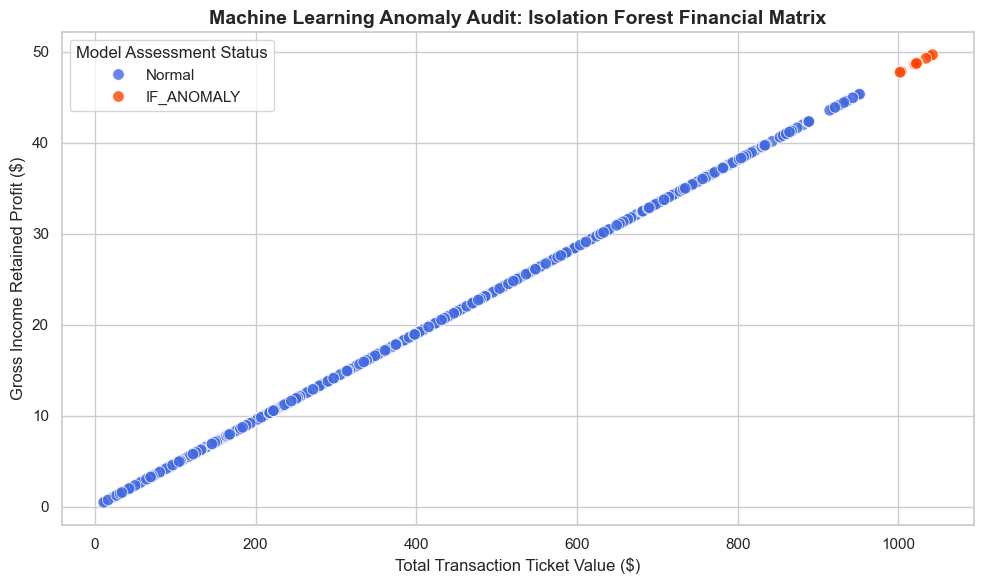

In [17]:
#Machine Learning Anomaly Audit (Scatter Plot)
plt.figure(figsize=(10, 6))
sales_col = 'total' if 'total' in df.columns else 'sales'

sns.scatterplot(
    data=df, 
    x=sales_col, 
    y='gross income', 
    hue='iforest_anomaly', 
    palette={'Normal': '#4169E1', 'IF_ANOMALY': '#FF4500'},
    alpha=0.8,
    s=70
)

plt.title('Machine Learning Anomaly Audit: Isolation Forest Financial Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Total Transaction Ticket Value ($)', fontsize=12)
plt.ylabel('Gross Income Retained Profit ($)', fontsize=12)
plt.legend(title='Model Assessment Status')
plt.tight_layout()
plt.show()


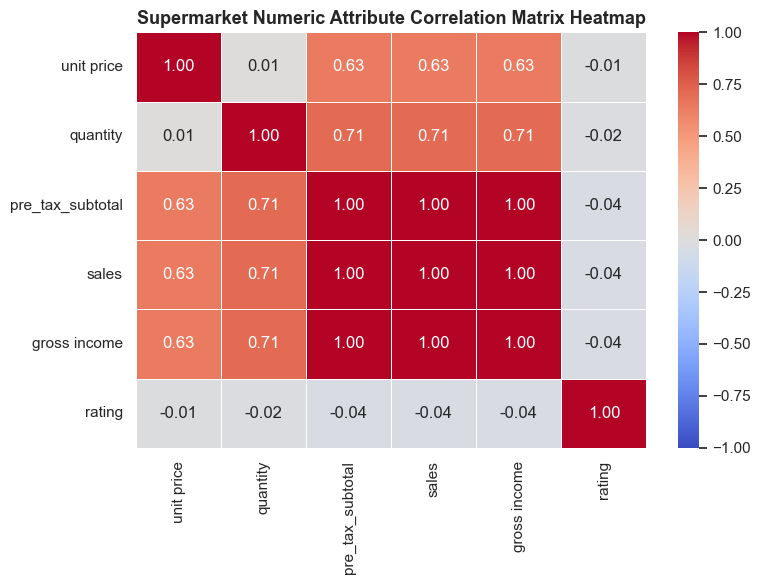

In [18]:
#Correlation Analysis
plt.figure(figsize=(8, 6))

sales_col = 'total' if 'total' in df.columns else 'sales'
subtotal_col = 'pre_tax_subtotal' if 'pre_tax_subtotal' in df.columns else 'cogs'


numerical_df = df[['unit price', 'quantity', subtotal_col, sales_col, 'gross income', 'rating']]
correlation_matrix = numerical_df.corr()


sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)

plt.title('Supermarket Numeric Attribute Correlation Matrix Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
